In [ ]:
import os 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import math
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch as ts
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report
)
# DOMAIN EXPANSION : INFINITE COMPUTAION
device = ts.device("cuda")

print(device)

df = pd.read_csv("jena_climate_2009_2016.csv")

df["Date Time"] = pd.to_datetime(df["Date Time"], dayfirst=True)

df = df.sort_values("Date Time")

print(df.head())
print(df.shape)


cuda
            Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0 2009-01-01 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1 2009-01-01 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2 2009-01-01 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3 2009-01-01 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4 2009-01-01 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03         

In [ ]:
# Keeping timestamp separately
timestamps = df["Date Time"]

# Selecting only numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Averageing 6 consecutive 10 minute readings
df_hourly = (df.groupby(df.index // 6)[numeric_cols].mean())

# one timestamp for each hour
df_hourly.insert(
    0,
    "Date Time",
    timestamps.groupby(df.index // 6).first().values
)

df = df_hourly

print(df.head())
print(df.shape)

            Date Time    p (mbar)  T (degC)    Tpot (K)  Tdew (degC)  \
0 2009-01-01 00:10:00  996.523333 -8.261667  265.161667    -9.063333   
1 2009-01-01 01:10:00  996.545000 -8.203333  265.221667    -9.026667   
2 2009-01-01 02:10:00  996.781667 -8.751667  264.653333    -9.591667   
3 2009-01-01 03:10:00  997.011667 -8.936667  264.450000    -9.846667   
4 2009-01-01 04:10:00  997.236667 -9.445000  263.923333   -10.450000   

      rh (%)  VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  \
0  93.883333      3.271667      3.071667      0.200000   1.918333   
1  93.733333      3.288333      3.081667      0.205000   1.926667   
2  93.583333      3.146667      2.945000      0.200000   1.840000   
3  93.050000      3.101667      2.885000      0.215000   1.803333   
4  92.316667      2.980000      2.751667      0.231667   1.718333   

   H2OC (mmol/mol)  rho (g/m**3)  wv (m/s)  max. wv (m/s)    wd (deg)  
0         3.081667   1308.973333  0.468333       0.940000  177.500000  
1       

In [49]:
features = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)"
]

data = df[features]

n = len(data)

train_end = int(0.7 * n)
val_end = int(0.9 * n)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

print(train_data.shape)
print(val_data.shape)
print(test_data.shape)

scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_data)

val_scaled = scaler.transform(val_data)

test_scaled = scaler.transform(test_data)

# separate scaler for temperature only
target_scaler = StandardScaler()
target_scaler.fit(train_data[['T (degC)']].values)

(49064, 14)
(14018, 14)
(7010, 14)


,copy,True
,with_mean,True
,with_std,True


In [ ]:
def create_sequences(data, seq_len=72, future=12):
    X = []
    y = []

    for i in range(len(data) - seq_len - future):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len:i+seq_len+future, 1])   # Temp

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled)
X_val, y_val = create_sequences(val_scaled)
X_test, y_test = create_sequences(test_scaled)

print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(48980, 72, 14)
(48980, 12)
(13934, 72, 14)
(13934, 12)
(6926, 72, 14)
(6926, 12)


In [51]:
class WeatherDataset(Dataset):
    def __init__(self, X, y):
        self.X = ts.tensor(X, dtype=ts.float32)
        self.y = ts.tensor(y, dtype=ts.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = WeatherDataset(X_train, y_train)
val_dataset = WeatherDataset(X_val, y_val)
test_dataset = WeatherDataset(X_test, y_test)

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

x, y = next(iter(train_loader))

print("Input Shape :", x.shape)
print("Target Shape:", y.shape)

Input Shape : torch.Size([64, 72, 14])
Target Shape: torch.Size([64, 12])


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = ts.zeros(max_len, d_model)

        position = ts.arange(0, max_len, dtype=ts.float32).unsqueeze(1)

        div_term = ts.exp(
            ts.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = ts.sin(position * div_term)
        pe[:, 1::2] = ts.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

pos_encoder = PositionalEncoding(d_model=64)

dummy = ts.zeros(32, 72, 64)

out = pos_encoder(dummy)

print(out.shape)

torch.Size([32, 72, 64])


In [ ]:
import torch.nn as nn
class TransformerForecast(nn.Module):

    def __init__(
        self,
        input_dim=14,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        output_steps=12
    ):
        super().__init__()

        # Input Embedding
        self.embedding = nn.Linear(input_dim, d_model)

        # Custom Positional Encoding
        self.pos_encoder = PositionalEncoding(d_model)

        # Transformer Encoder Layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        # Stack Encoder Layers
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Prediction Head
        self.fc = nn.Linear(d_model, output_steps)

    def forward(self, x):

        # (Batch,72,14) -> (Batch,72,64)
        x = self.embedding(x)

        # Adding positional information
        x = self.pos_encoder(x)

        # Transformer Encoder
        x = self.transformer(x)

        # Mean Pooling over sequence length
        x = x.mean(dim=1)

        # Prediction on next 12 temperatures
        x = self.fc(x)

        return x

In [88]:
device = ts.device("cuda")

model = TransformerForecast().to(device)


In [ ]:
# checking parameters 
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 68,684
Trainable Parameters : 68,684


In [81]:
criterion = nn.MSELoss()

optimizer = ts.optim.Adam(
    model.parameters(),
    lr=0.0001
)

epochs = 25

train_loss = []
val_loss = []

best_loss = float("inf")

for epoch in range(epochs):

    # Training 
    model.train()

    running_train_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)

    train_loss.append(epoch_train_loss)

    # Validation 
    model.eval()

    running_val_loss = 0

    with ts.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)

    val_loss.append(epoch_val_loss)

    # Best Model
    if epoch_val_loss < best_loss:

        best_loss = epoch_val_loss

        ts.save(model.state_dict(), "best_transformer.pth")

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {epoch_train_loss:.6f} | "
        f"Val Loss: {epoch_val_loss:.6f}"
    )

Epoch [1/25] | Train Loss: 0.025808 | Val Loss: 0.062234
Epoch [2/25] | Train Loss: 0.025165 | Val Loss: 0.063493
Epoch [3/25] | Train Loss: 0.024839 | Val Loss: 0.062089
Epoch [4/25] | Train Loss: 0.024564 | Val Loss: 0.062904
Epoch [5/25] | Train Loss: 0.024351 | Val Loss: 0.063624
Epoch [6/25] | Train Loss: 0.024089 | Val Loss: 0.062980
Epoch [7/25] | Train Loss: 0.023914 | Val Loss: 0.065565
Epoch [8/25] | Train Loss: 0.023619 | Val Loss: 0.064310
Epoch [9/25] | Train Loss: 0.023436 | Val Loss: 0.065018
Epoch [10/25] | Train Loss: 0.023205 | Val Loss: 0.068654
Epoch [11/25] | Train Loss: 0.022993 | Val Loss: 0.066131
Epoch [12/25] | Train Loss: 0.022851 | Val Loss: 0.065137
Epoch [13/25] | Train Loss: 0.022574 | Val Loss: 0.067078
Epoch [14/25] | Train Loss: 0.022419 | Val Loss: 0.066102
Epoch [15/25] | Train Loss: 0.022117 | Val Loss: 0.065485
Epoch [16/25] | Train Loss: 0.021941 | Val Loss: 0.066500
Epoch [17/25] | Train Loss: 0.021769 | Val Loss: 0.067325
Epoch [18/25] | Train L

In [82]:
model.load_state_dict(ts.load("best_transformer.pth"))

model.eval()

C:\Users\njnin\AppData\Local\Temp\ipykernel_8276\2152568875.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(ts.load("best_transformer.pth"))


TransformerForecast(
  (embedding): Linear(in_features=14, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=12, bias=True)
)

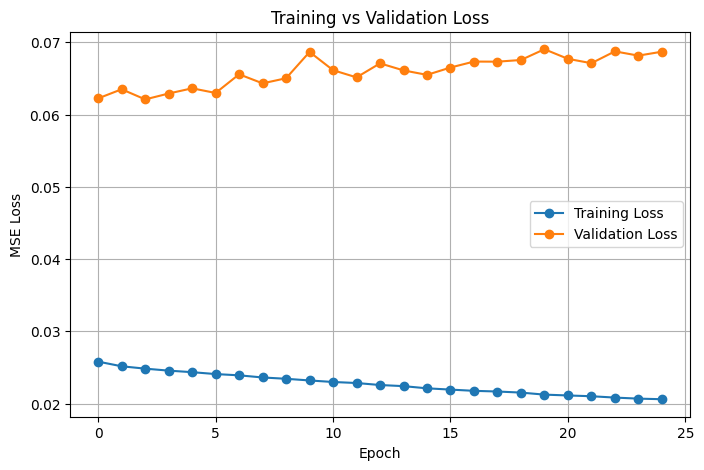

In [83]:
plt.figure(figsize=(8,5))

plt.plot(train_loss, label="Training Loss", marker="o")
plt.plot(val_loss, label="Validation Loss", marker="o")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# loading the best model
model.load_state_dict(ts.load("best_transformer.pth"))

model.eval()

predictions = []
actuals = []

with ts.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.append(outputs.cpu().numpy())
        actuals.append(y_batch.numpy())

predictions = np.concatenate(predictions, axis=0)
actuals = np.concatenate(actuals, axis=0)

print(predictions.shape)
print(actuals.shape)

C:\Users\njnin\AppData\Local\Temp\ipykernel_8276\3414536714.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(ts.load("best_transformer.pth"))


(6926, 12)
(6926, 12)


In [ ]:
# evalution matrix
temp_mean = scaler.mean_[1]
temp_std = scaler.scale_[1]

predictions_inv = predictions * temp_std + temp_mean
actuals_inv = actuals * temp_std + temp_mean
y_true = actuals_inv.flatten()
y_pred = predictions_inv.flatten()

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

r2 = r2_score(y_true, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 1.3742
RMSE : 1.8728
R²   : 0.9423


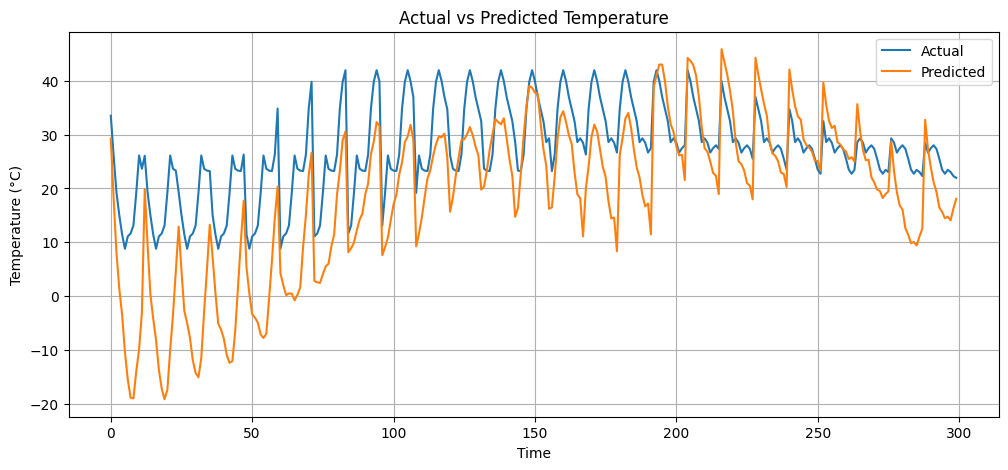

In [86]:
# inverse transform correctly using target_scaler
y_true_actual = target_scaler.inverse_transform(
    y_true.reshape(-1, 1)
)
y_pred_actual = target_scaler.inverse_transform(
    y_pred.reshape(-1, 1)  
)

plt.figure(figsize=(12,5))
plt.plot(y_true_actual[:300], label="Actual")
plt.plot(y_pred_actual[:300], label="Predicted")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Actual vs Predicted Temperature")
plt.legend()
plt.grid(True)
plt.show()


Discussion

The custom LSTM exhibited more stable training, with both training and validation losses decreasing consistently over the training period. In contrast, the Transformer converged more rapidly during the initial epochs but began to overfit after Epoch 3, as evidenced by the widening gap between training and validation losses. This suggests that the Transformer benefited from early stopping or stronger regularization to achieve optimal generalization. Despite this, the Transformer remains advantageous for modeling long-range dependencies through self-attention, whereas the LSTM offers more stable learning dynamics for this forecasting task.

   Best Validation Loss  :                
    LSTM 	 =   0.0491 
    Transformer = 0.0621 
